# Exercise 4B. Classification, shallow learning, model evaluation and prediction

The aim of exercise 4 is to learn how to:
* train shallow learning models
* use the trained model to predict an whole image
* evaluate the models accuracy
* see what features mostly contribute to the results

The task is land-use classification, based on 2 datasets: Sentinel-2 11-days mosaic and Google AlphaEarth data.

This exercise is split to 2 notebooks:
* `04A_shallow_classification_model_training.ipynb` for model training
* This notebook for models evaluation and prediction.

**04A notebook must be run twice (with Sentinel-2 and AlphaEarth data) before this one**

## Results
For each model (2 datasets x 2 models)
* Model accuracy estimation
* Class confusion matrix
* Predicted classification as GeoTIFFs
* Insight what features are important for the model

Models:
* Sentinel-2 + Random forest
* Sentinel-2 + Histogram-based Gradient Boosting Classification Tree
* AlphaEarth data + Random forest
* AlphaEarth data + Histogram-based Gradient Boosting Classification Tree

In [1]:
import os, time
from joblib import dump, load
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
import pandas as pd
import rasterio
from rasterio.plot import show
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
%matplotlib inline

In [21]:
# Set folders and file paths
user = os.environ.get('USER')
base_folder = os.path.join('/scratch/project_2019932/students', user, 'GeoML')
dataFolder = os.path.join(base_folder,'data', 'raster', 'pixel-wise')
results_folder = os.path.join(base_folder, "classification_results")
classification_report_csv = os.path.join(results_folder, "classification_report_results.csv")
if not os.path.exists(results_folder):
    os.makedirs(results_folder)

exerciseFolder= os.path.join(base_folder,'04_shallow_classification')
os.chdir(exerciseFolder)

# Source data local paths
multiclass_classification_file = os.path.join(dataFolder, 'labels.tif')

datasets = ["sentinel2", "alphaearth"]
models = ["random_forest", "hist_gradient_boosting"]

# Saved input files from exercise 2.
data_files = {
    datasets[0]: os.path.join(dataFolder, 'data_sentinel2.tif'),
    datasets[1]: os.path.join(dataFolder, 'data_alphaearth.tif')
}

# Saved test data from 4A
test_data_files = {
    datasets[0]: datasets[0] + "_test_data.npz",
    datasets[1]: datasets[1] + "_test_data.npz"
}

# The saved models from 4A
model_files = {
    (datasets[0],models[0]): "model_" + datasets[0] + "_" + models[0] + ".sav",
    (datasets[0],models[1]): "model_" + datasets[0] + "_" + models[1] + ".sav",
    (datasets[1],models[0]): "model_" + datasets[1] + "_" + models[0] + ".sav",
    (datasets[1],models[1]): "model_" + datasets[1] + "_" + models[1] + ".sav"
}

# Paths for GeoTIFF created below
predicted_classification = {
    (datasets[0],models[0]): os.path.join(results_folder, ('classification_' + datasets[0] + '_' + models[0] +  '.tif')),
    (datasets[0],models[1]): os.path.join(results_folder, ('classification_' + datasets[0] + '_' + models[1] +  '.tif')),
    (datasets[1],models[0]): os.path.join(results_folder, ('classification_' + datasets[1] + '_' + models[0] +  '.tif')),
    (datasets[1],models[1]): os.path.join(results_folder, ('classification_' + datasets[1] + '_' + models[1] +  '.tif'))
}

In [3]:
#Give classes and bands names for plotting
class_names = ["other", "forest", "fields", "water"]

band_names = {
    datasets[0]: ["b02", "b03", "b04", "b05", "b06", "b07", "b08", "b8a", "b11", "b12"],
    datasets[1]: [str(i) for i in range(1, 65)]
}

## Estimate models with test data

Load the models from the saved files. Here and below, each step is done for all 4 models.

In [4]:
trained_models = {}

for key, filepath in model_files.items():
    trained_models[key] = load(filepath)

trained_models

{('sentinel2',
  'random_forest'): RandomForestClassifier(max_depth=75, n_estimators=200, n_jobs=1, random_state=0),
 ('sentinel2', 'hist_gradient_boosting'): HistGradientBoostingClassifier(),
 ('alphaearth',
  'random_forest'): RandomForestClassifier(max_depth=75, n_estimators=200, n_jobs=1, random_state=0),
 ('alphaearth', 'hist_gradient_boosting'): HistGradientBoostingClassifier()}

Load the test data from the saved files

In [5]:
test_data = {}

for key, filepath in test_data_files.items():
    data = np.load(filepath)
    test_data[(key,"x")] = data["X_test"]
    test_data[(key,"y")] = data["y_test"]

#test_data

Calculate precitions for test data.

In [6]:
test_predictions = {}

for key, path in model_files.items():
    dataset, model = key
    clf = trained_models[(dataset,model)]
    test_predictions[key] = clf.predict(test_data[(dataset,"x")])

## Classification reports

In [7]:
for key, path in model_files.items():
    dataset, model = key
    print(model, dataset)
    print('Classification report: \n', classification_report(test_data[(dataset,"y")], test_predictions[key]))

random_forest sentinel2
Classification report: 
               precision    recall  f1-score   support

           0       0.32      0.52      0.40     12602
           1       0.95      0.86      0.91     78502
           2       0.84      0.82      0.83     40630
           3       0.81      0.92      0.86      6046

    accuracy                           0.82    137780
   macro avg       0.73      0.78      0.75    137780
weighted avg       0.86      0.82      0.84    137780

hist_gradient_boosting sentinel2
Classification report: 
               precision    recall  f1-score   support

           0       0.32      0.50      0.39     12602
           1       0.96      0.86      0.91     78502
           2       0.83      0.82      0.83     40630
           3       0.79      0.91      0.84      6046

    accuracy                           0.82    137780
   macro avg       0.72      0.77      0.74    137780
weighted avg       0.85      0.82      0.83    137780

random_forest alphaeart

Save the results for later comparision.

In [8]:
classification_report_results = {}

# Get the same classification report as JSON
for key, path in model_files.items():
    dataset, model = key
    classification_report_results[key] = classification_report(test_data[(dataset,"y")], test_predictions[key], output_dict=True)

# Convert to Pandas dataframe
df = pd.json_normalize(list(classification_report_results.values()))
df.insert(0, "dataset", [k[0] for k in classification_report_results.keys()])
df.insert(1, "model", [k[1] for k in classification_report_results.keys()])

# Save the dataframe
df.to_csv(classification_report_csv, index=False)

# Have a look on the dataframe
df.head()

,dataset,model,accuracy,0.precision,0.recall,0.f1-score,0.support,1.precision,1.recall,1.f1-score,...,3.f1-score,3.support,macro avg.precision,macro avg.recall,macro avg.f1-score,macro avg.support,weighted avg.precision,weighted avg.recall,weighted avg.f1-score,weighted avg.support
0,sentinel2,random_forest,0.821411,0.322271,0.520156,0.397972,12602.0,0.954817,0.862488,0.906307,...,0.860230,6046.0,0.731249,0.781240,0.748852,137780.0,0.857036,0.821411,0.835553,137780.0
1,sentinel2,hist_gradient_boosting,0.820620,0.320383,0.496667,0.389508,12602.0,0.956045,0.864742,0.908105,...,0.841571,6046.0,0.723263,0.772509,0.741505,137780.0,0.853419,0.820620,0.833786,137780.0
2,alphaearth,random_forest,0.885666,0.483026,0.715839,0.576827,12602.0,0.971583,0.881086,0.924124,...,0.948795,6046.0,0.830816,0.868541,0.843378,137780.0,0.907822,0.885666,0.893335,137780.0
3,alphaearth,hist_gradient_boosting,0.884374,0.481452,0.719886,0.577007,12602.0,0.971786,0.877519,0.922250,...,0.944472,6046.0,0.824714,0.872354,0.841942,137780.0,0.907177,0.884374,0.892175,137780.0


## Confusion matrices

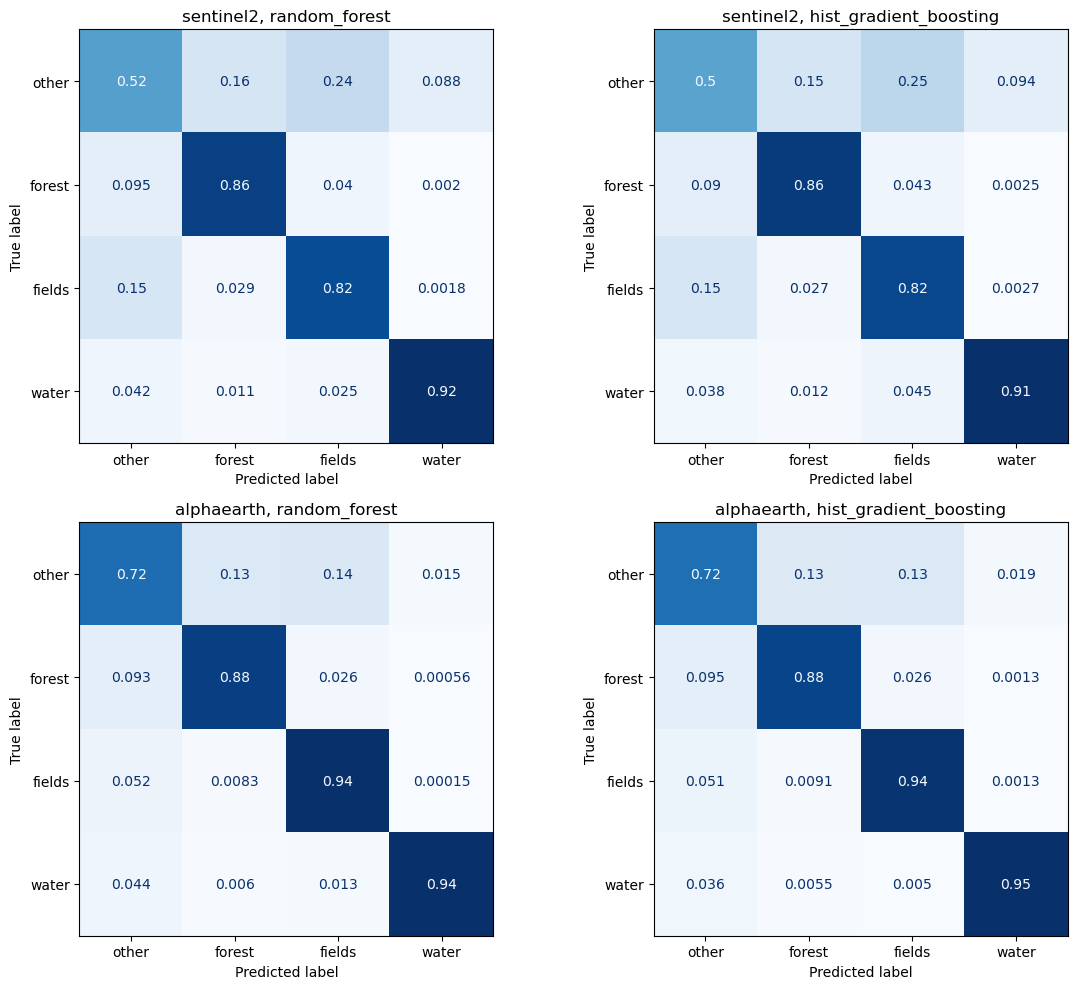

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (key, path) in zip(axes.flat, model_files.items()):
    dataset, model = key

    disp = ConfusionMatrixDisplay.from_predictions(
        test_data[(dataset, "y")],
        test_predictions[key],
        normalize='true',
        cmap=plt.cm.Blues,
        display_labels=class_names,
        ax=ax,
        colorbar=False
    )
    ax.set_title(f"{dataset}, {model}")

plt.tight_layout()
plt.show()

### Predict classification based on the data image and save it

In [23]:
def predictImage(dataset, model):
    start_time = time.time()    

    # Read the pixel values from .tif file as dataframe
    with rasterio.open(data_files[dataset]) as image_dataset:
        image_data = image_dataset.read()
        no_bands_in_image = image_data.shape[0]
        image_data2 = np.transpose(image_data, (1, 2, 0))
        pixels = image_data2.reshape(-1, no_bands_in_image)
    
        # predict the class for each pixel
        trained_model = trained_models[(dataset, model)]
        prediction = trained_model.predict(pixels)
    
        # Reshape back to 2D
        prediction2D = np.reshape(prediction, (image_data.shape[1], image_data.shape[2]))
    
        # Save the results as .tif file.
        # Copy metadata from the labels image
        profile = image_dataset.meta.copy()
        profile.update(dtype=rasterio.uint16, count=1, nodata=2000)
        # Writing the image on the disk
        prediction_file = predicted_classification[(dataset, model)]
        with rasterio.open(prediction_file, 'w', **profile) as dst:
            dst.write(prediction2D, 1)
        print('Predicting took: ', dataset, model, round((time.time() - start_time), 1), ' seconds')

In [24]:
for key, path in model_files.items():
    dataset, model = key
    predictImage(dataset,model)

Predicting took:  sentinel2 random_forest 28.3  seconds
Predicting took:  sentinel2 hist_gradient_boosting 16.0  seconds
Predicting took:  alphaearth random_forest 34.7  seconds
Predicting took:  alphaearth hist_gradient_boosting 18.9  seconds


## 4.6 Plot the results

In [12]:
# For better plotting of Sentinel image, normalize the values
# Help function to normalize band values and enhance contrast. Just like what QGIS does automatically
def normalize(rgb):
    min_percent = 2   # Low percentile
    max_percent = 98  # High percentile
    lo, hi = np.percentile(rgb, (min_percent, max_percent), axis=(0,1), keepdims=True)
    new_min, new_max = 1, 255
    rgb_norm = (rgb - lo) / (hi - lo) * (new_max - new_min) + new_min
    rgb_norm = rgb_norm.astype(np.uint8)    
    return rgb_norm.astype(np.uint8)

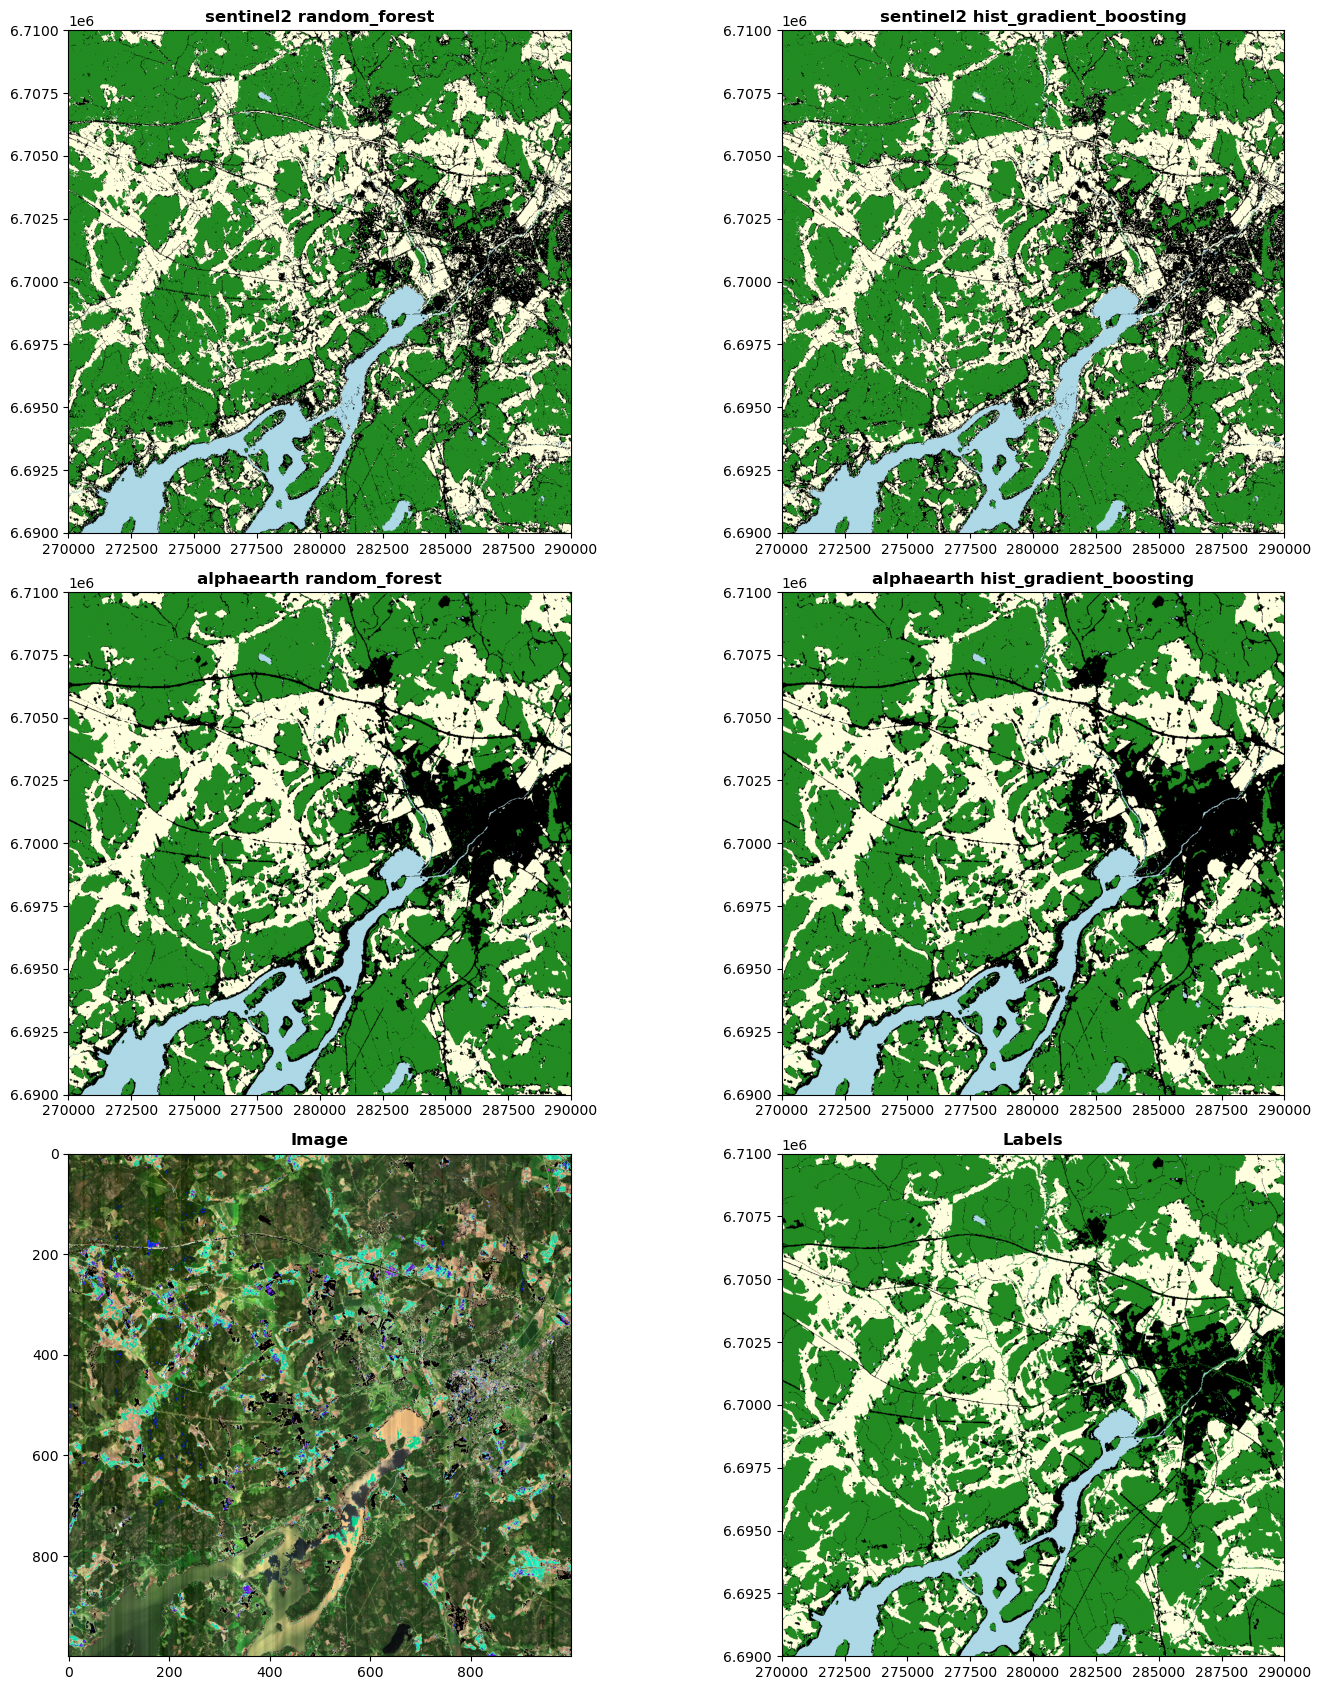

In [26]:
# Create a subplot for 6 images: 4 classification, 1 data image and 1 training labels. 
fig, axes = plt.subplots(ncols=2, nrows=3, figsize=(15,17))
cmap = ListedColormap(["black", "forestgreen", "lightyellow", "lightblue"])
for ax, (key, path) in zip(axes.flat, model_files.items()):
    dataset, model = key
    title = f"{dataset} {model}"

    with rasterio.open(predicted_classification[(dataset, model)]) as src:
        show(src, ax=ax, cmap=cmap, title=title)

# Plot the sentinel image 
with rasterio.open(data_files["sentinel2"]) as image_data:
    rgb = image_data.read([3, 2, 1])
    rgb_norm = normalize(rgb)
    show(rgb_norm, ax=axes[2,0], title='Image') 

# Labels 
with rasterio.open(multiclass_classification_file) as labels:
    show(labels, ax=axes[2,1], cmap=cmap,  title='Labels') 

plt.tight_layout()
plt.show()

## What features are important?

Random forest classifier provides also feature importances. Histogram-based Gradient Boosting Classification Tree does not have that option.

In [14]:
for key, model in trained_models.items():
    dataset, model_name = key
    if model_name == "random_forest":
        print(key)    
        print('Feature importances:')
        importances = list(zip(band_names[dataset], model.feature_importances_))
        # Sort descending by importance value
        importances_sorted = sorted(importances, key=lambda x: x[1], reverse=True)
        
        for importance in importances_sorted[:10]:
            print(importance)

('sentinel2', 'random_forest')
Feature importances:
('b12', np.float64(0.1607635942822605))
('b11', np.float64(0.12780122744759784))
('b08', np.float64(0.11135768867962476))
('b8a', np.float64(0.10376088880032845))
('b03', np.float64(0.1010233218774236))
('b07', np.float64(0.09395916504843581))
('b02', np.float64(0.07901106734162368))
('b05', np.float64(0.07696922262392149))
('b04', np.float64(0.0729566436853893))
('b06', np.float64(0.07239718021339463))
('alphaearth', 'random_forest')
Feature importances:
('49', np.float64(0.05876976497822131))
('58', np.float64(0.04821447510427564))
('46', np.float64(0.04428173698154786))
('56', np.float64(0.04149201895328365))
('57', np.float64(0.03465912258392215))
('25', np.float64(0.03402678145607556))
('15', np.float64(0.03257019929154921))
('62', np.float64(0.031692395481132805))
('26', np.float64(0.03156692636815459))
('64', np.float64(0.030184991269263585))


## SHAP

We can also use SHAP (SHapley Additive exPlanations) to gain some insight of our model and our predictions. SHAP estimates how an individual feature has influenced predictions made by the model. For tree-based models such as RF, SHAP provides an especially efficient way to find each features' contribution by tracing back the decision path made by the model. This way it is able to compute all of the SHAP values exactly. 

In [15]:
# Get data for SHAP - extract a number of pixels from the data
# The number of pixels is very low here to keep the running time suitable for a course
# Otherwise take at least 100 points.
shap_data = {}

for dataset in datasets:
    X_full = test_data[(dataset, "x")]
    rng = np.random.default_rng(seed=42)
    idx = rng.choice(len(X_full), size=30, replace=False) # Increase the size here to get more datapoints.
    shap_data[dataset] = X_full[idx]

In [16]:
# Calculate SHAP values
shap_values = {}

for key, path in model_files.items():
    dataset, model = key

    clf = trained_models[(dataset, model)]
    explainer = shap.TreeExplainer(clf)
    shap_values[key] = explainer.shap_values(shap_data[dataset])

The SHAP bar summary plot shows the average impact of each input feature on the model's predictions, ranked from most to least important. For each feature, the bar length represents the mean absolute SHAP value across all samples — how much, on average, that feature pushed predictions away from the baseline (in either direction). It shows which features matter most overall, but not how they affect predictions (i.e. no positive/negative direction). In a multiclass setting, each bar is broken down by class, showing each feature's average contribution to predicting each class separately.

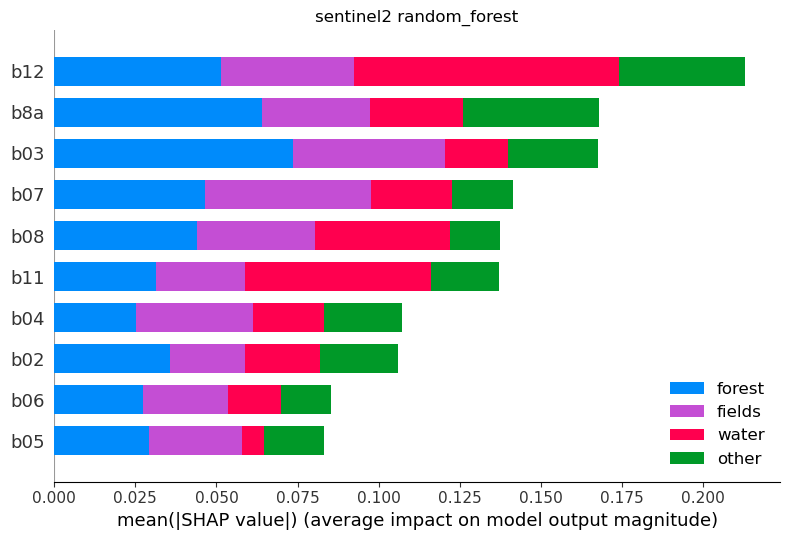

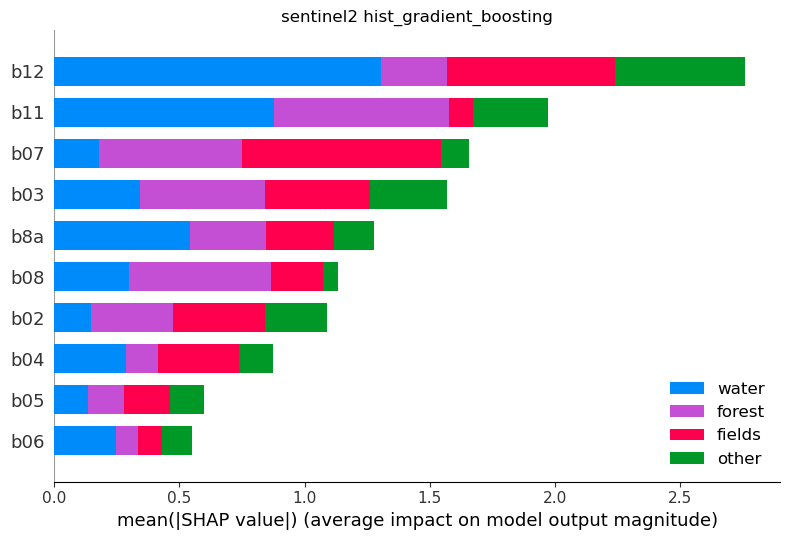

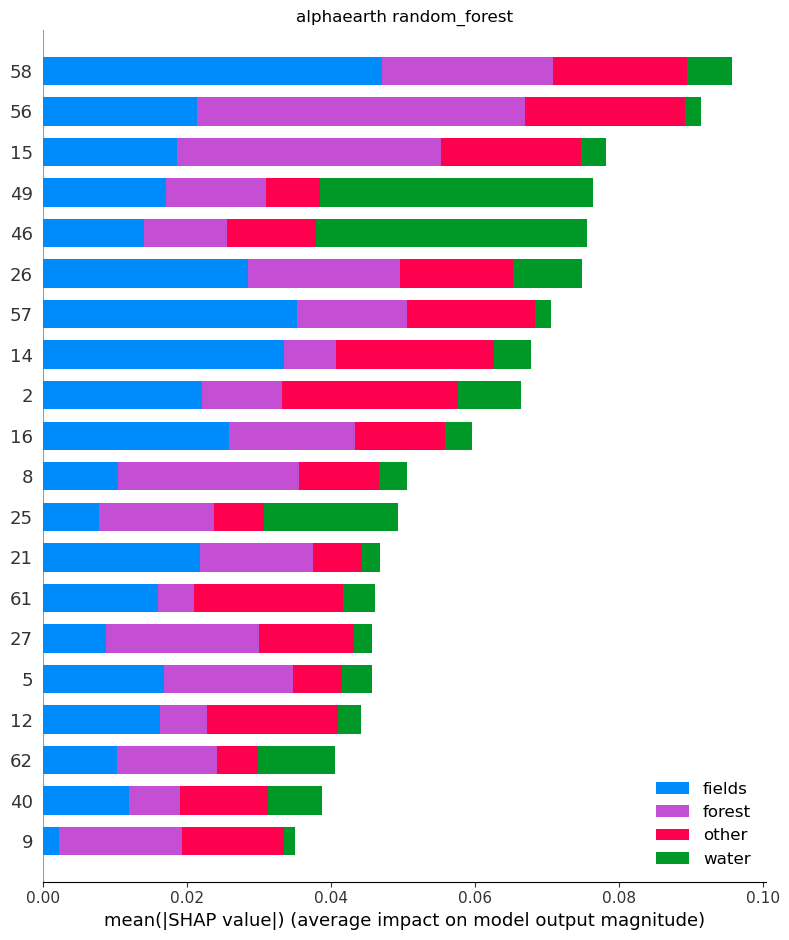

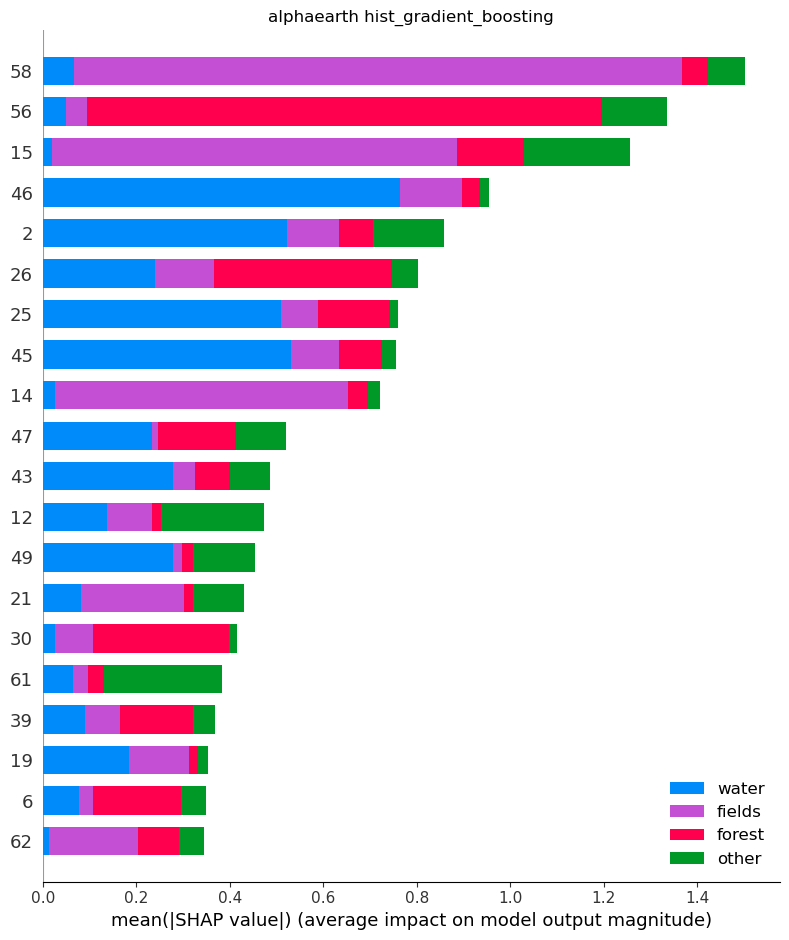

In [17]:
for key, path in model_files.items():
    dataset, model = key

    shap.summary_plot(
        shap_values[key], shap_data[dataset],
        plot_type="bar",
        feature_names=band_names[dataset],
        class_names=class_names,
        show=False
    )
    
    title = f"{dataset} {model}"   
    plt.title(title)
    plt.tight_layout()
    plt.show()

The SHAP violin plot shows how each feature affects the model's prediction for a specific class, across all samples. Each point is one sample; its position on the x-axis shows the SHAP value — how much that feature pushed the prediction toward (positive) or away from (negative) this class for that sample. Point color typically shows the feature's actual value (e.g. red = high, blue = low), so you can see not just which features matter, but how their values relate to the direction of their effect. Features are ranked top-to-bottom by overall importance for this class.

Unlike the aggregated bar plot, this view is class-specific — it isolates the model's reasoning for a single class, showing which feature values push samples toward or away from being predicted as that class. Comparing these plots across classes can reveal whether the same feature drives different (or opposite) predictions depending on the class.

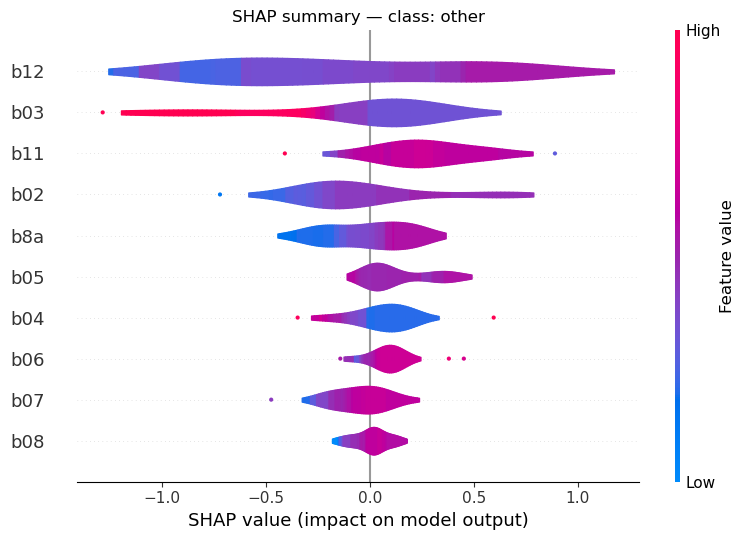

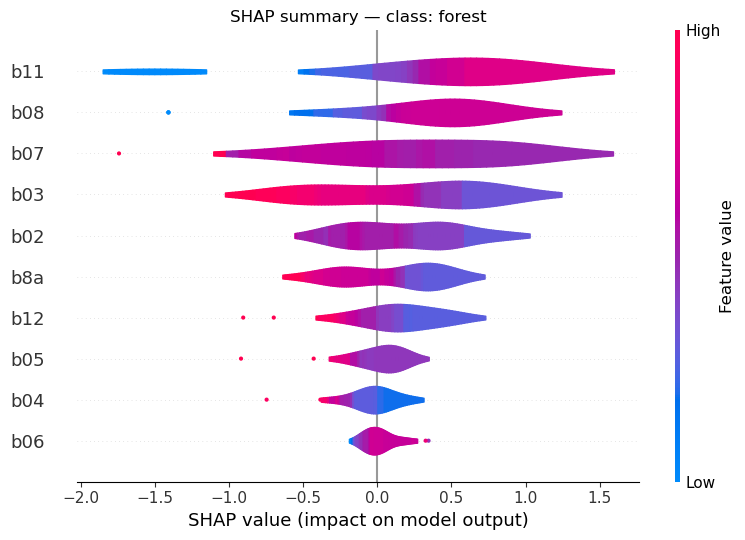

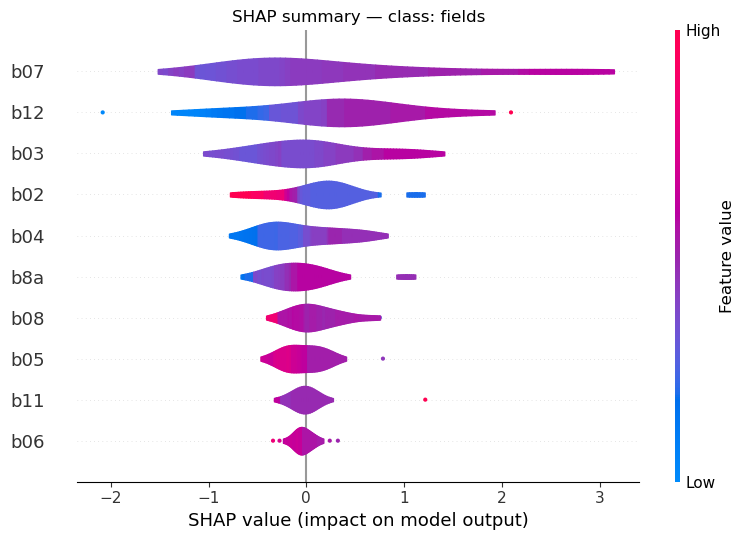

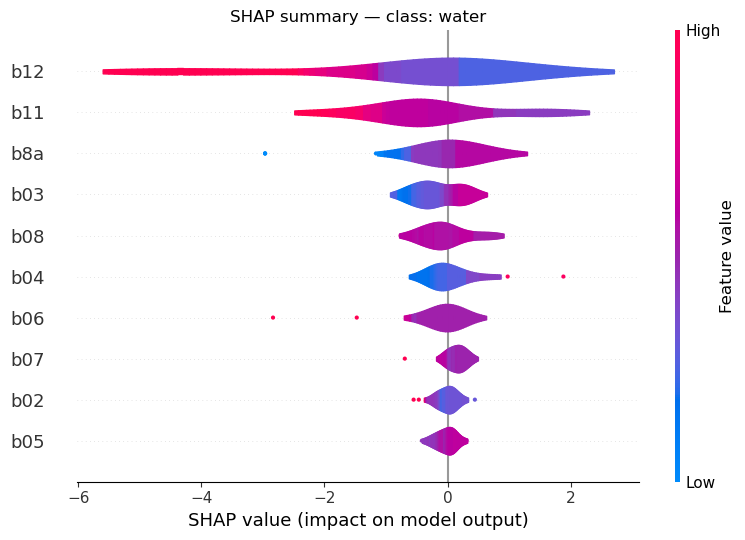

In [18]:
# The last plot is only for one model, change to other models, if you want
dataset = "sentinel2" 
#dataset = "alphaearth"
#model_name = "random_forest" 
model_name = "hist_gradient_boosting"

for i, class_name in enumerate(class_names):
    shap_class_i = shap_values[(dataset,model_name)][:, :, i]   

    shap.summary_plot(
        shap_class_i,
        shap_data[dataset],
        feature_names=band_names[dataset],
        plot_type="violin",
        show=False
    )
    plt.title(f"SHAP summary — class: {class_name}")
    plt.tight_layout()
    plt.show()